### Цель исследования

В этом ноутбуке сравниваются два подхода к оптимизации: **градиентный спуск** и **метод Нелдера - Мида**.\
Проверка проводится на трех тестовых функциях с разной геометрией поверхности: хорошо обусловленная квадратичная, плохо обусловленная квадратичная и функция Розенброка.

Далее последовательно выполняются:
1. подбор шага обучения для градиентного спуска
2. запуск обоих методов с одинаковыми начальными точками
3. сравнение метрик качества и стоимости вычислений
4. визуальный анализ траекторий и динамики ошибок


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scr.BlackBox import (
    make_well_conditioned_quadratic_6,
    make_bad_conditioned_quadratic_4,
    make_rosenbrock_3,
)
from scr.ToolsResearch import (
    CountingBox,
    reference_minimum,
    tune_learning_rate,
    run_method,
    nelder_mead_trace,
    f_slice_2d,
    to_cn_vector,
    int_log10,
    fraction_log10,
    cn_half_width,
    epsilon_dynamics_on_trajectory,
)

In [2]:
FUNCTIONS = {
    "quadratic_good_6": {
        "factory": make_well_conditioned_quadratic_6,
        "x0": [2.0, -3.0, 1.0, 0.5, -1.5, 2.5],
    },
    "quadratic_bad_4": {
        "factory": make_bad_conditioned_quadratic_4,
        "x0": [3.0, -3.0, 2.0, -2.0],
    },
    "rosenbrock_3": {
        "factory": make_rosenbrock_3,
        "x0": [-1.2, 1.0, 0.8],
    },
}

LR_GRID = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

lr_tables = {}
best_lr = {}

for fname, cfg in FUNCTIONS.items():
    df_lr, lr = tune_learning_rate(cfg["factory"], cfg["x0"], LR_GRID, max_iter=3000, tol=1e-8)
    lr_tables[fname] = df_lr
    best_lr[fname] = lr

print("Подобранные learning rate:")
for k, v in best_lr.items():
    print(f"{k}: {v}")


Подобранные learning rate:
quadratic_good_6: 0.3
quadratic_bad_4: 0.3
rosenbrock_3: 0.1


По результатам перебора сетки:

Для квадратичных функций большие шаги дают быструю сходимость, тогда как для функции Розенброка даже лучший шаг обеспечивает более медленное и менее устойчивое поведение GD.
На следующем шаге используем найденные `lr` и сравним GD с Нелдера - Мида по единым метрикам.

In [3]:
runs = {}
rows = []

for fname, cfg in FUNCTIONS.items():
    x_star, f_star = reference_minimum(cfg["factory"])

    gd_run = run_method(
        cfg["factory"],
        cfg["x0"],
        method="gradient_descent",
        x_star=x_star,
        f_star=f_star,
        learning_rate=best_lr[fname],
        max_iter=4000,
        tol=1e-8,
    )

    nm_run = run_method(
        cfg["factory"],
        cfg["x0"],
        method="nelder_mead",
        x_star=x_star,
        f_star=f_star,
        step=1.0,
        max_iter=4000,
        tol=1e-8,
    )

    nm_traj, nm_hist = nelder_mead_trace(
        cfg["factory"], cfg["x0"], step=1.0, max_iter=4000, tol=1e-8
    )

    runs[fname] = {
        "x_star": x_star,
        "f_star": f_star,
        "gd": gd_run,
        "nm": nm_run,
        "nm_traj": nm_traj,
        "nm_hist_trace": nm_hist,
    }

    row_gd = {"function": fname, "best_lr": best_lr[fname], **gd_run["row"]}
    row_nm = {"function": fname, "best_lr": np.nan, **nm_run["row"]}
    rows.extend([row_gd, row_nm])

results_df = pd.DataFrame(rows)
results_df = results_df[
    ["function", "method", "converged", "iterations", "time_sec", "f_calls", "g_calls", "f_best", "f_gap", "x_err_l2", "best_lr"]
].sort_values(["function", "method"])

results_df


,function,method,converged,iterations,time_sec,f_calls,g_calls,f_best,f_gap,x_err_l2,best_lr
2,quadratic_bad_4,gradient_descent,True,899,0.016286,5389,899,-7.475000e-01,-2.220446e-16,7.200403e-09,0.3
3,quadratic_bad_4,nelder_mead,True,121,0.003523,1421,0,-7.475000e-01,2.756060e-09,6.370971e-05,NaN
0,quadratic_good_6,gradient_descent,True,65,0.001691,137,65,-3.958979e+00,-4.440892e-16,8.529733e-09,0.3
1,quadratic_good_6,nelder_mead,True,203,0.014646,3159,0,-3.958979e+00,1.054858e-08,1.477201e-04,NaN
4,rosenbrock_3,gradient_descent,False,4000,0.041320,30023,4000,1.183155e-06,1.183155e-06,2.219361e-03,0.1
5,rosenbrock_3,nelder_mead,True,213,0.002604,2068,0,3.477676e-09,3.477676e-09,9.402997e-05,NaN


Оба метода успешно сошлись на квадратичных функциях, но с разным профилем затрат:
- на `quadratic_good_6` быстрее по итерациям и времени оказался GD (`65` против `203`);
- на `quadratic_bad_4` быстрее оказался Нелдера - Мида (`121` против `899`).

На функции `rosenbrock_3` наблюдается ключевое различие:
- GD не выполнил критерий остановки за лимит `4000` итераций;
- Nelder-Mead сошелся за `213` итераций и дал малый функциональный зазор.

Эффективность метода существенно зависит от ландшафта функции; универсального лидера по всем задачам нет.

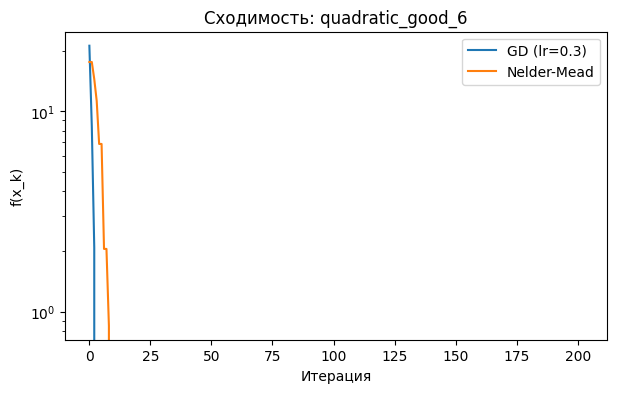

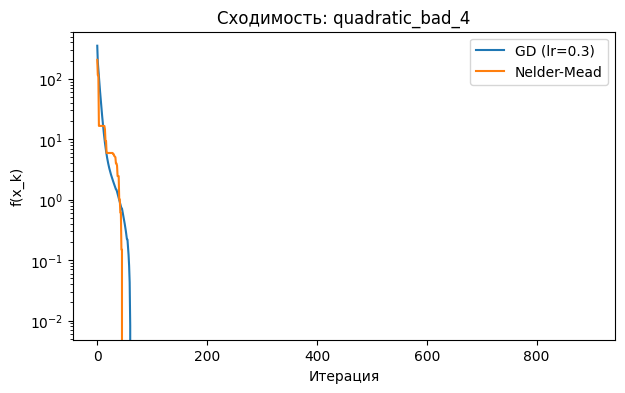

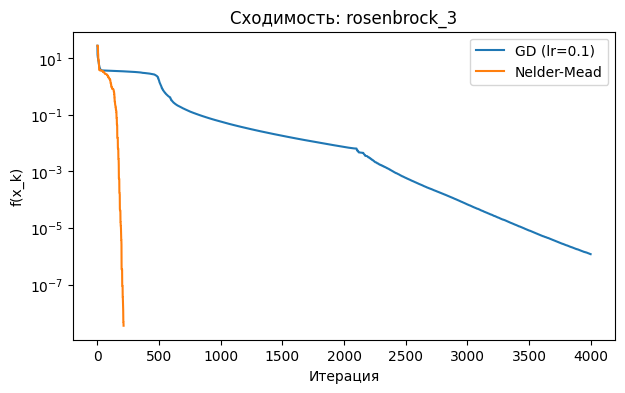

In [4]:
for fname, data in runs.items():
    plt.figure(figsize=(7, 4))
    gd_hist = np.array(data["gd"]["history"], dtype=float)
    nm_hist = np.array(data["nm"]["history"], dtype=float)

    plt.plot(gd_hist, label=f"GD (lr={best_lr[fname]:g})")
    plt.plot(nm_hist, label="Nelder-Mead")
    plt.yscale("log")
    plt.xlabel("Итерация")
    plt.ylabel("f(x_k)")
    plt.title(f"Сходимость: {fname}")
    plt.legend()
    plt.show()


Графики позволяют оценить скорость убывания функционала и стабильность шага:
- на квадратичных задачах обе кривые убывают монотонно, но темп у методов различается
- для Розенброка у GD спад заметно более медленный, у Нелдера - Мида же на этой же функции убывание более уверенное и приводит к достижению критерия

Далее проверим это визуально через траектории движения в пространстве переменных.

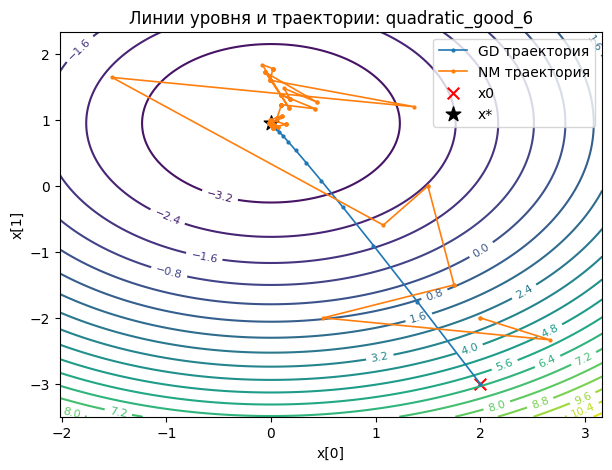

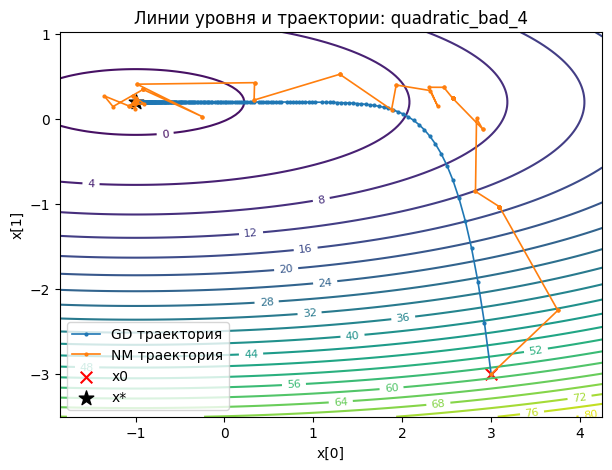

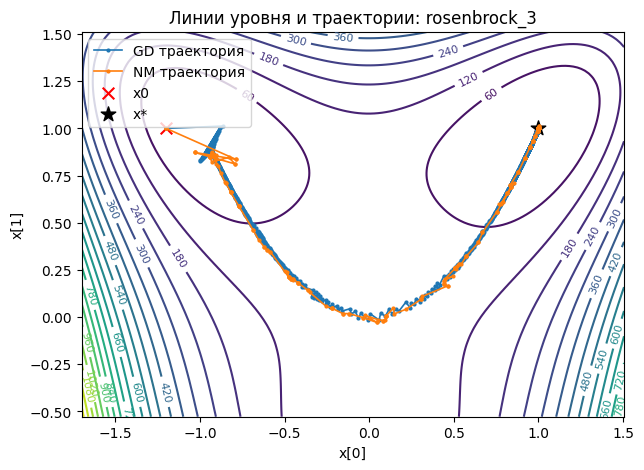

In [5]:
for fname, cfg in FUNCTIONS.items():
    x_star = runs[fname]["x_star"]
    x0 = np.array(cfg["x0"], dtype=float)

    gd_traj = runs[fname]["gd"]["trajectory_gd"]
    nm_traj = runs[fname]["nm_traj"]

    if gd_traj is None or len(gd_traj) == 0 or len(nm_traj) == 0:
        continue

    x_min = min(gd_traj[:, 0].min(), nm_traj[:, 0].min(), x0[0], x_star[0]) - 0.5
    x_max = max(gd_traj[:, 0].max(), nm_traj[:, 0].max(), x0[0], x_star[0]) + 0.5
    y_min = min(gd_traj[:, 1].min(), nm_traj[:, 1].min(), x0[1], x_star[1]) - 0.5
    y_max = max(gd_traj[:, 1].max(), nm_traj[:, 1].max(), x0[1], x_star[1]) + 0.5

    xx = np.linspace(x_min, x_max, 140)
    yy = np.linspace(y_min, y_max, 140)
    X, Y = np.meshgrid(xx, yy)

    f2d = f_slice_2d(cfg["factory"], x_star, i=0, j=1)
    Z = np.vectorize(f2d)(X, Y)

    plt.figure(figsize=(7, 5))
    cs = plt.contour(X, Y, Z, levels=20)
    plt.clabel(cs, inline=True, fontsize=8)

    plt.plot(gd_traj[:, 0], gd_traj[:, 1], "-o", ms=2, lw=1.2, label="GD траектория")
    plt.plot(nm_traj[:, 0], nm_traj[:, 1], "-o", ms=2, lw=1.2, label="NM траектория")

    plt.scatter([x0[0]], [x0[1]], c="red", marker="x", s=70, label="x0")
    plt.scatter([x_star[0]], [x_star[1]], c="black", marker="*", s=120, label="x*")

    plt.xlabel("x[0]")
    plt.ylabel("x[1]")
    plt.title(f"Линии уровня и траектории: {fname}")
    plt.legend()
    plt.show()


Траектории на линиях уровня показывают, как геометрия функции влияет на путь оптимизации:
- на квадратичных функциях путь к минимуму предсказуемый
- на более сложном рельефе (Розенброк) у GD движение чувствительно к узкой долине, что приводит к длинной траектории
- Нелдера - Мида адаптирует форму симплекса и проходит сложные участки устойчивее.

Следующий этап фиксирует этот эффект через динамику `epsilon_f` для разных начальных значений точности.

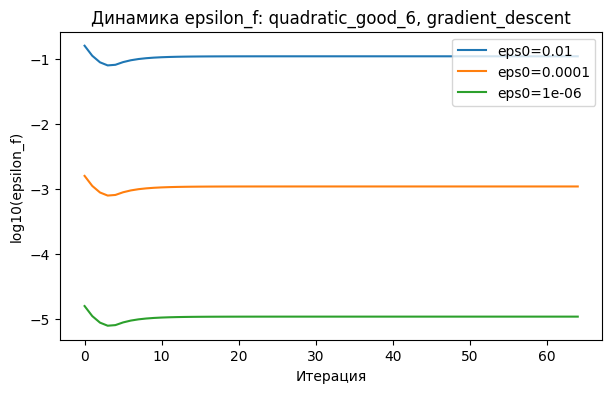

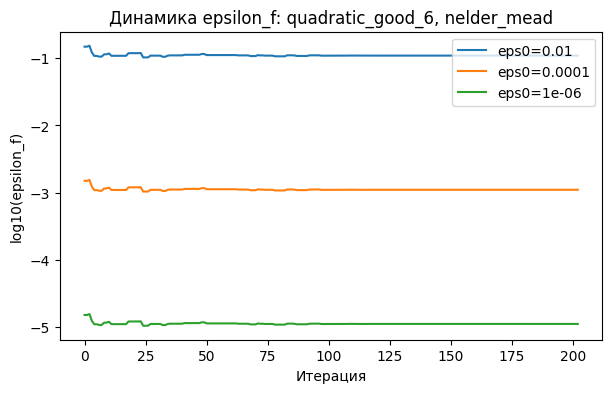

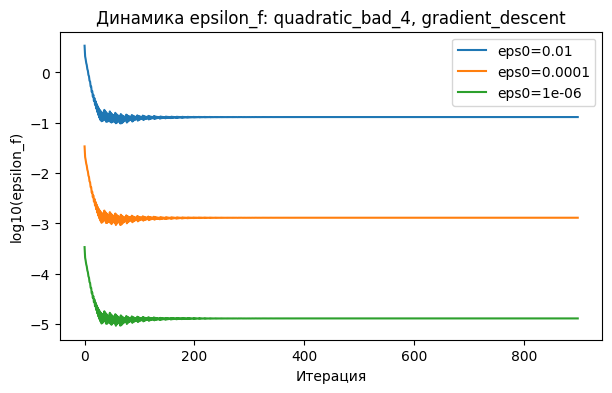

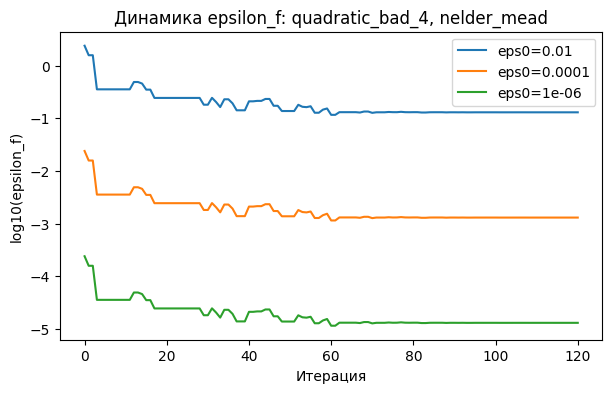

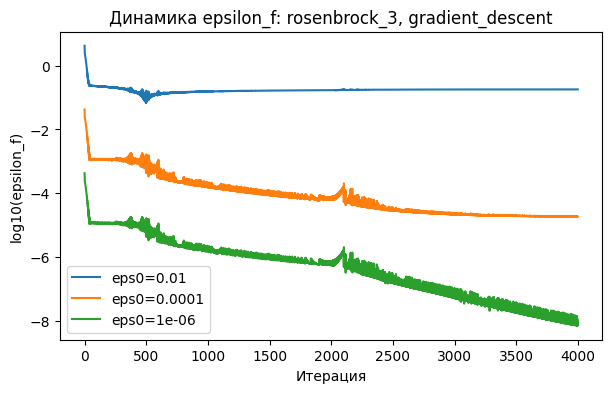

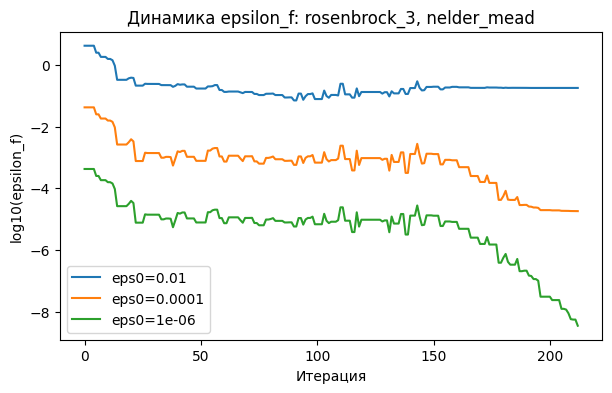

,function,method,eps0,iters_used,final_log10_eps_f,max_log10_eps_f
8,quadratic_bad_4,gradient_descent,0.000001,899,-4.886057,-3.469160
7,quadratic_bad_4,gradient_descent,0.000100,899,-2.886057,-1.469160
6,quadratic_bad_4,gradient_descent,0.010000,899,-0.886057,0.530840
11,quadratic_bad_4,nelder_mead,0.000001,121,-4.886062,-3.620694
10,quadratic_bad_4,nelder_mead,0.000100,121,-2.886062,-1.620694
9,quadratic_bad_4,nelder_mead,0.010000,121,-0.886062,0.379306
2,quadratic_good_6,gradient_descent,0.000001,65,-4.958607,-4.795880
1,quadratic_good_6,gradient_descent,0.000100,65,-2.958605,-2.795880
0,quadratic_good_6,gradient_descent,0.010000,65,-0.958410,-0.795880
5,quadratic_good_6,nelder_mead,0.000001,203,-4.958604,-4.811306


In [6]:
EPS_LIST = [1e-2, 1e-4, 1e-6]

eps_rows = []
for fname, cfg in FUNCTIONS.items():
    gd_traj = runs[fname]["gd"]["trajectory_gd"]
    nm_traj = runs[fname]["nm_traj"]

    for method, traj in [("gradient_descent", gd_traj), ("nelder_mead", nm_traj)]:
        if traj is None or len(traj) == 0:
            continue

        plt.figure(figsize=(7, 4))
        for eps0 in EPS_LIST:
            log_eps = epsilon_dynamics_on_trajectory(cfg["factory"], traj, eps0)
            plt.plot(log_eps, label=f"eps0={eps0:g}")

            eps_rows.append({
                "function": fname,
                "method": method,
                "eps0": eps0,
                "iters_used": len(log_eps),
                "final_log10_eps_f": float(log_eps[-1]),
                "max_log10_eps_f": float(np.max(log_eps)),
            })

        plt.xlabel("Итерация")
        plt.ylabel("log10(epsilon_f)")
        plt.title(f"Динамика epsilon_f: {fname}, {method}")
        plt.legend()
        plt.show()

eps_df = pd.DataFrame(eps_rows).sort_values(["function", "method", "eps0"])
eps_df


Для каждого метода и каждой функции рассмотрены три масштаба начальной точности: `1e-2`, `1e-4`, `1e-6`.
Из таблицы видно, что число использованных итераций соответствует фактической длине траектории метода на задаче.

На функции Розенброка итоговые значения у Нелдера - Мида достигают более глубоких уровней при меньшем числе шагов, чем у GD.
На квадратичных функциях различия между методами меньше, и оба подхода обеспечивают малую итоговую ошибку.


In [7]:
print("--- Топ-3 learning rate по каждой функции")
for fname, df_lr in lr_tables.items():
    print(f"\n{fname}")
    display(df_lr.head(3))

print("\n---Основные метрики методов")
display(results_df)

print("\n---Метрики динамики epsilon")
display(eps_df)


--- Топ-3 learning rate по каждой функции

quadratic_good_6


,lr,converged,f_best,iterations,time_sec,f_calls,g_calls
7,0.30,True,-3.958979,65,0.002672,137,65
6,0.10,False,-3.958979,3000,0.331146,78910,3000
5,0.03,False,-3.958979,3000,0.356687,70759,3000



quadratic_bad_4


,lr,converged,f_best,iterations,time_sec,f_calls,g_calls
7,0.30,True,-0.7475,899,0.016846,5389,899
4,0.01,True,-0.7475,2026,0.015471,4221,2026
6,0.10,False,-0.7475,3000,0.245406,80338,3000



rosenbrock_3


,lr,converged,f_best,iterations,time_sec,f_calls,g_calls
6,0.10,False,0.000068,3000,0.034133,22601,3000
7,0.30,False,0.000069,3000,0.038663,29110,3000
4,0.01,False,0.000182,3000,0.020195,14526,3000



---Основные метрики методов


,function,method,converged,iterations,time_sec,f_calls,g_calls,f_best,f_gap,x_err_l2,best_lr
2,quadratic_bad_4,gradient_descent,True,899,0.016286,5389,899,-7.475000e-01,-2.220446e-16,7.200403e-09,0.3
3,quadratic_bad_4,nelder_mead,True,121,0.003523,1421,0,-7.475000e-01,2.756060e-09,6.370971e-05,NaN
0,quadratic_good_6,gradient_descent,True,65,0.001691,137,65,-3.958979e+00,-4.440892e-16,8.529733e-09,0.3
1,quadratic_good_6,nelder_mead,True,203,0.014646,3159,0,-3.958979e+00,1.054858e-08,1.477201e-04,NaN
4,rosenbrock_3,gradient_descent,False,4000,0.041320,30023,4000,1.183155e-06,1.183155e-06,2.219361e-03,0.1
5,rosenbrock_3,nelder_mead,True,213,0.002604,2068,0,3.477676e-09,3.477676e-09,9.402997e-05,NaN



---Метрики динамики epsilon


,function,method,eps0,iters_used,final_log10_eps_f,max_log10_eps_f
8,quadratic_bad_4,gradient_descent,0.000001,899,-4.886057,-3.469160
7,quadratic_bad_4,gradient_descent,0.000100,899,-2.886057,-1.469160
6,quadratic_bad_4,gradient_descent,0.010000,899,-0.886057,0.530840
11,quadratic_bad_4,nelder_mead,0.000001,121,-4.886062,-3.620694
10,quadratic_bad_4,nelder_mead,0.000100,121,-2.886062,-1.620694
9,quadratic_bad_4,nelder_mead,0.010000,121,-0.886062,0.379306
2,quadratic_good_6,gradient_descent,0.000001,65,-4.958607,-4.795880
1,quadratic_good_6,gradient_descent,0.000100,65,-2.958605,-2.795880
0,quadratic_good_6,gradient_descent,0.010000,65,-0.958410,-0.795880
5,quadratic_good_6,nelder_mead,0.000001,203,-4.958604,-4.811306


## Общие выводы исследования

1. Подбор `learning rate` критичен для GD: на простых рельефах он дает очень быстрый результат, но на сложной геометрии может не сойтись в разумный лимит итераций.
2. Нелдера - Мида показал более устойчивое поведение на неоднородных поверхностях (в частности, на функции Розенброка), хотя на части задач требует больше вычислений функции.
3. Для квадратичных задач оба метода достигают близкого качества решения, различия проявляются в скорости.
4. Анализ траекторий и динамики `epsilon_f` подтверждает: выбор метода должен учитывать структуру функции, а не только размерность.